<a href="https://colab.research.google.com/github/phungngocbich/phungngocbich.com/blob/code_model_nckh/CNN_LSTM_GoogleTrends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib-venn
!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy


E: Package 'libfluidsynth1' has no installation candidate
Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 124947 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.3_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.3) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.3) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.5 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31631 sha256=4c1dea601e4169d45d938d1ad376d035bf36dcf926cfb64fbb6232491e72edf8
  Stored in directory: /root/.cache/pip/wheels/32/98/bd/4893d6923dd027f455b250367d402bfd69a6f4416581df46db
Successfully built libarchive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 96.0 MB/s eta 0:00:00


In [ ]:
pip install pytrends

# **Import thư viện**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Conv1D, LSTM, Dense, Dropout

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, MaxPooling1D
import matplotlib.pyplot as plt

# **LÀM SẠCH DỮ LIỆU**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dữ liệu Google Trends (thay thế 'google_trends.csv' bằng file thực tế)
df = pd.read_csv('/content/drive/MyDrive/DATANCKH/trends_filtered_2020_2025.csv', delimiter=',', encoding='utf-8')
df = df.dropna()  # Xóa giá trị NaN nếu có

In [ ]:
# 1. Chuyển đổi cột 'date' sang kiểu datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Loại bỏ các dòng trùng lặp
df_cleaned = df.drop_duplicates()

# 3. Kiểm tra và loại bỏ các giá trị bị thiếu
df_cleaned = df_cleaned.dropna()

# 4. Chuẩn hóa lại tên cột
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace(" ", "_")

# Lưu lại file đã làm sạch
cleaned_file_path = "DATASET_CLEANED.csv"
df_cleaned.to_csv(cleaned_file_path, index=False)


In [ ]:
#In dữ liệu đã làm sạch
print(df_cleaned)
total_keywords = df['keyword'].nunique() # Thay 'Keyword' bằng tên cột chứa keyword
print(f"Tổng số keyword: {total_keywords}")

            date      keyword  interest_over_time
0     2020-03-15  AI Security                   5
1     2020-03-22  AI Security                   5
2     2020-03-29  AI Security                   5
3     2020-04-05  AI Security                   5
4     2020-04-12  AI Security                   5
...          ...          ...                 ...
12262 2025-02-09   Zero Trust                  74
12263 2025-02-16   Zero Trust                  83
12264 2025-02-23   Zero Trust                  77
12265 2025-03-02   Zero Trust                  74
12266 2025-03-09   Zero Trust                  76

[12267 rows x 3 columns]
Tổng số keyword: 47


# **MÔ HÌNH CNN-LSTM**

In [ ]:
# Kiểm tra dữ liệu
print(df_cleaned)

            date      keyword  interest_over_time
0     2020-03-15  AI Security                   5
1     2020-03-22  AI Security                   5
2     2020-03-29  AI Security                   5
3     2020-04-05  AI Security                   5
4     2020-04-12  AI Security                   5
...          ...          ...                 ...
12262 2025-02-09   Zero Trust                  74
12263 2025-02-16   Zero Trust                  83
12264 2025-02-23   Zero Trust                  77
12265 2025-03-02   Zero Trust                  74
12266 2025-03-09   Zero Trust                  76

[12267 rows x 3 columns]


Tiền xử lý dữ liệu

In [ ]:
# Tiền xử lý dữ liệu
df_cleaned = df_cleaned[['date', 'keyword', 'interest_over_time']]
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
df_cleaned.dropna(inplace=True)

# Khởi tạo MinMaxScaler
scaler_X = MinMaxScaler(feature_range=(0,1))
scaler_y = MinMaxScaler(feature_range=(0,1))

# Use scaler_X or scaler_y instead of 'scaler'
df_cleaned['trend_value_scaled'] = scaler_X.fit_transform(df_cleaned[['interest_over_time']]) # or scaler_y, depending on your intention

# Fit scaler_y to the target variable 'interest_over_time' before scaling
scaler_y.fit(df_cleaned[['interest_over_time']]) # This line is added to fit scaler_y

MinMaxScaler()

In [ ]:
# Tạo tập dữ liệu theo từ khóa
keywords = df_cleaned['keyword'].unique()
datasets = {keyword: df_cleaned[df_cleaned['keyword'] == keyword]['trend_value_scaled'].values for keyword in keywords} # Thay 'trend_value' bằng 'trend_value_scaled'

# Sắp xếp các từ khóa theo cột
keyword_df_cleaned = pd.DataFrame(keywords, columns=['Từ khóa'])
print(keyword_df_cleaned.to_string(index=True))  # In ra DataFrame mà không có chỉ số

                       Từ khóa
0                  AI Security
1                   AR Glasses
2            Adaptive learning
3                   Applied AI
4            Augmented reality
5                  Bioprinting
6                       CRISPR
7               Carbon Capture
8             Cashless Payment
9                     Chatbots
10     Cloud computing for IoT
11   Cloud computing platforms
12             Computer vision
13           Distributed Cloud
14                     Edge AI
15                         FDM
16               Generative AI
17              Green Hydrogen
18       Green cloud computing
19           Industrial Robots
20      IoT security and trust
21              Lab-grown Meat
22                       LiDAR
23                   Metaverse
24                         NFT
25                         NLP
26               Nano robotics
27             Network Slicing
28                Public Cloud
29        Quantum Cryptography
30           Quantum computing
31      

In [ ]:
# Khởi tạo các tham số Sliding Window
window_size = 10
step_size = 5
train_ratio = 0.8

In [ ]:
# Tạo Sliding Window
def create_sequences(df_cleaned, window_size=10, step_size=5):  # Thay đổi window_size và step_size nếu cần
    sequences, labels = [], []
    for i in range(0, len(df_cleaned) - window_size, step_size):  # Thêm step_size để trượt cửa sổ
        sequences.append(df_cleaned[i:i + window_size])
        labels.append(df_cleaned[i + window_size])
    return np.array(sequences), np.array(labels)

In [ ]:
# Chia tập huấn luyện và kiểm tra
X_train_dict, X_test_dict, y_train_dict, y_test_dict = {}, {}, {}, {}

# Khởi tạo data_dict để lưu trữ dữ liệu cho từng keyword
data_dict = {}

for keyword in keywords:
    # Lấy dữ liệu cho keyword hiện tại và tạo sliding window
    data = df_cleaned[df_cleaned['keyword'] == keyword]['trend_value_scaled'].values
    X, y = create_sequences(data, window_size, step_size)

    # Chia train-test 80-20
    split_idx = int(len(X) * train_ratio)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Lưu dữ liệu vào data_dict
    data_dict[keyword] = (X, y)

    X_train_dict[keyword] = X_train
    X_test_dict[keyword] = X_test
    y_train_dict[keyword] = y_train
    y_test_dict[keyword] = y_test


    # In ra thông tin
    print(f"\n🔹 {keyword}:")
    print(f"  Tổng số cửa sổ trượt: {len(X)}")
    print(f"  Số tập train: {len(X_train)}")
    print(f"  Số tập test: {len(X_test)}")

   # In ra tất cả cửa sổ của mỗi từ khóa
    print(f"\n🔹 {keyword}: Tổng số cửa sổ trượt = {len(X)}")
    for i in range(len(X)):
        print(f"  Window {i+1}: {X[i]} → {y[i]}")


🔹 AI Security:
  Tổng số cửa sổ trượt: 51
  Số tập train: 40
  Số tập test: 11

🔹 AI Security: Tổng số cửa sổ trượt = 51
  Window 1: [0.05 0.05 0.05 0.05 0.05 0.06 0.06 0.06 0.06 0.06] → 0.05
  Window 2: [0.06 0.06 0.06 0.06 0.06 0.05 0.05 0.05 0.05 0.06] → 0.04
  Window 3: [0.05 0.05 0.05 0.05 0.06 0.04 0.05 0.06 0.07 0.05] → 0.06
  Window 4: [0.04 0.05 0.06 0.07 0.05 0.06 0.06 0.06 0.06 0.06] → 0.05
  Window 5: [0.06 0.06 0.06 0.06 0.06 0.05 0.06 0.06 0.06 0.05] → 0.06
  Window 6: [0.05 0.06 0.06 0.06 0.05 0.06 0.05 0.06 0.05 0.05] → 0.05
  Window 7: [0.06 0.05 0.06 0.05 0.05 0.05 0.05 0.06 0.05 0.05] → 0.04
  Window 8: [0.05 0.05 0.06 0.05 0.05 0.04 0.04 0.04 0.05 0.06] → 0.05
  Window 9: [0.04 0.04 0.04 0.05 0.06 0.05 0.05 0.06 0.05 0.06] → 0.06
  Window 10: [0.05 0.05 0.06 0.05 0.06 0.06 0.06 0.06 0.05 0.04] → 0.05
  Window 11: [0.06 0.06 0.06 0.05 0.04 0.05 0.05 0.06 0.06 0.05] → 0.04
  Window 12: [0.05 0.05 0.06 0.06 0.05 0.04 0.06 0.06 0.06 0.09] → 0.07
  Window 13: [0.04 0.06

In [ ]:
# 5. Gộp dữ liệu từ tất cả các từ khóa
X_train_all = [X_train_dict[keyword] for keyword in keywords]  # Tạo list chứa dữ liệu train cho tất cả keywords
y_train_all = [y_train_dict[keyword] for keyword in keywords]  # Tạo list chứa dữ liệu target cho tất cả keywords
X_test_all = [X_test_dict[keyword] for keyword in keywords]  # Tạo list chứa dữ liệu test cho tất cả keywords
y_test_all = [y_test_dict[keyword] for keyword in keywords]  # Tạo list chứa dữ liệu target cho tất cả keywords

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_test = np.concatenate(X_test_all)
y_test = np.concatenate(y_test_all)

Xây dựng mô hình CNN-LSTM

In [ ]:
# Định dạng lại dữ liệu cho mô hình CNN-LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
from tensorflow.keras.optimizers import Adam # Import Adam optimizer
# Xây dựng mô hình CNN-LSTM
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),  # Giảm overfitting
    LSTM(50),
    Dense(25),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 8, 64)               │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 4, 100)              │          66,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4, 100)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 97,757 (381.86 KB)

 Trainable params: 97,757 (381.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình CNN-LSTM
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0362 - val_loss: 0.0105
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0103 - val_loss: 0.0104
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0097 - val_loss: 0.0095
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0108 - val_loss: 0.0097
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0115 - val_loss: 0.0100
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0098 - val_loss: 0.0089
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0083 - val_loss: 0.0076
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0074 - val_loss: 0.0120
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0094 - val_loss: 0.0071
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0077 - val_loss: 0.0078
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9m

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hàm tính MAPE tránh lỗi chia cho 0
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0  # Loại bỏ các phần tử bằng 0 để tránh lỗi chia cho 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Dự đoán kết quả với mô hình CNN-LSTM
y_pred = model.predict(X_test)

# Chuyển về thang đo gốc bằng scaler_Y (do scaler_X không phù hợp với dữ liệu đầu ra)
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Tính toán các chỉ số đánh giá
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

# In kết quả đánh giá với định dạng tối ưu
print("\n--- Đánh giá mô hình CNN-LSTM ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")

#  Kiểm tra nếu R2 < 0, có thể mô hình đang underfitting
if r2 < 0:
    print(" Cảnh báo: Mô hình có thể chưa học được mối quan hệ trong dữ liệu (Underfitting).")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

--- Đánh giá mô hình CNN-LSTM ---
MAE: 5.7230
RMSE: 8.3441
R2 Score: 0.8995
MAPE: 15.5831%


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hàm tính MAPE tránh lỗi chia cho 0
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0  # Loại bỏ các phần tử bằng 0 để tránh lỗi chia cho 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Hàm đánh giá mô hình
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, mape, rmse, r2

# Khởi tạo từ điển lưu kết quả đánh giá cho từng từ khóa
results = {}

# Dự đoán kết quả với mô hình CNN-LSTM cho từng từ khóa
for keyword in keywords:
    data = df_cleaned[df_cleaned['keyword'] == keyword]['trend_value_scaled'].values
    X, y = create_sequences(data, window_size, step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))  # Định dạng lại để phù hợp với CNN-LSTM

    y_pred_keyword = model.predict(X)

    # Chuyển về thang đo gốc bằng scaler_Y
    y_pred_keyword_original = scaler_y.inverse_transform(y_pred_keyword.reshape(-1, 1)).flatten()
    y_original = scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()

    # Tính toán các chỉ số đánh giá
    mae, mape, rmse, r2 = evaluate_model(y_original, y_pred_keyword_original)
    results[keyword] = (mae, mape, rmse, r2)

# In kết quả đánh giá của từng từ khóa
print("\n--- Đánh giá mô hình CNN-LSTM cho từng từ khóa ---")
for keyword, (mae, mape, rmse, r2) in results.items():
    print(f"\n **{keyword}**:")
    print(f"   MAE: {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   R2 Score: {r2:.4f}")
    print(f"   MAPE: {mape:.4f}%")

    #  Kiểm tra nếu R2 < 0, có thể mô hình đang underfitting
    if r2 < 0:
        print("    Cảnh báo: Mô hình có thể chưa học được mối quan hệ trong dữ liệu (Underfitting).")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


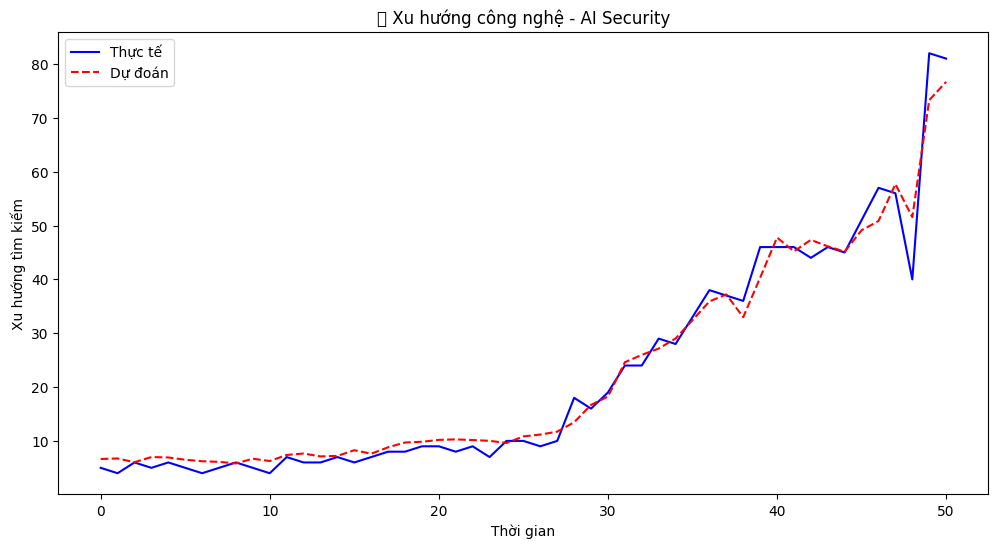

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


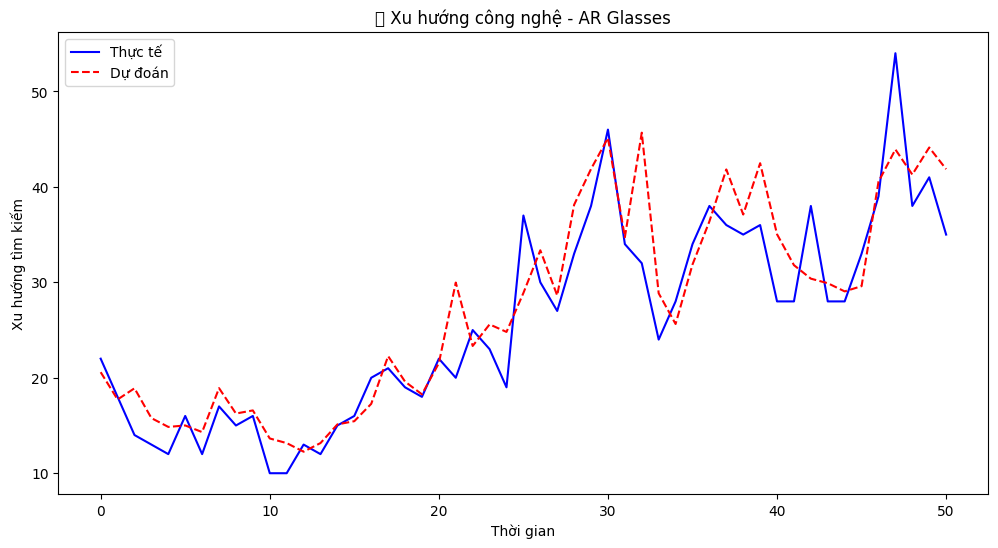

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


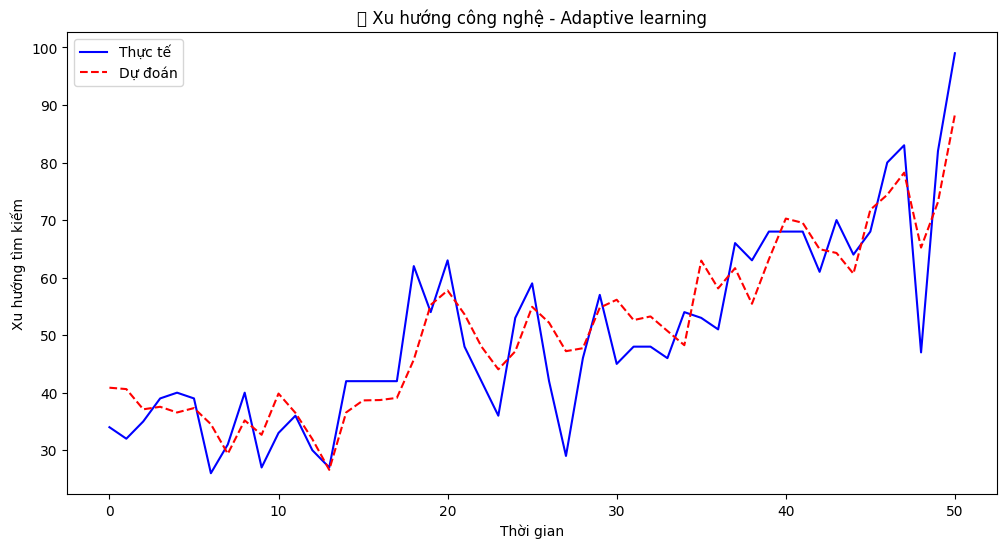

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


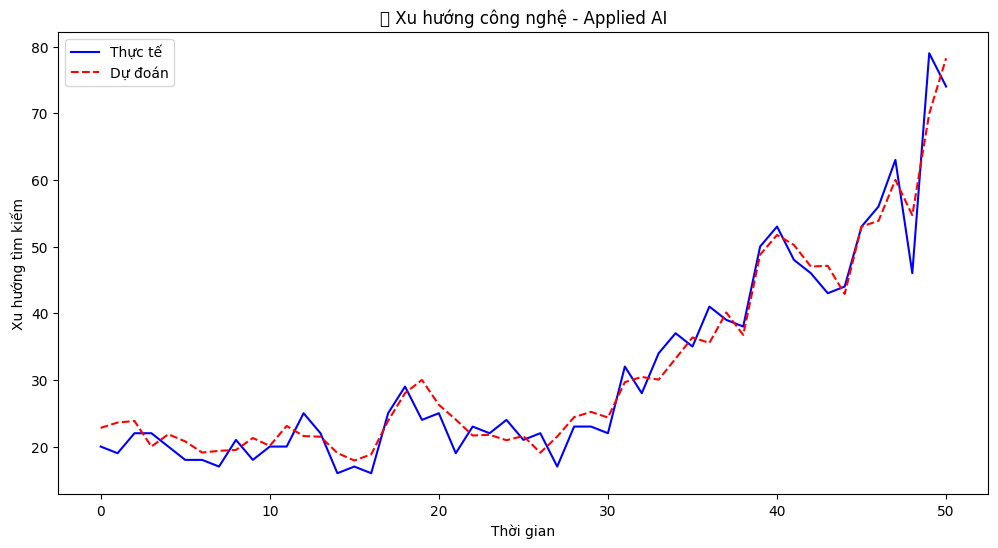

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


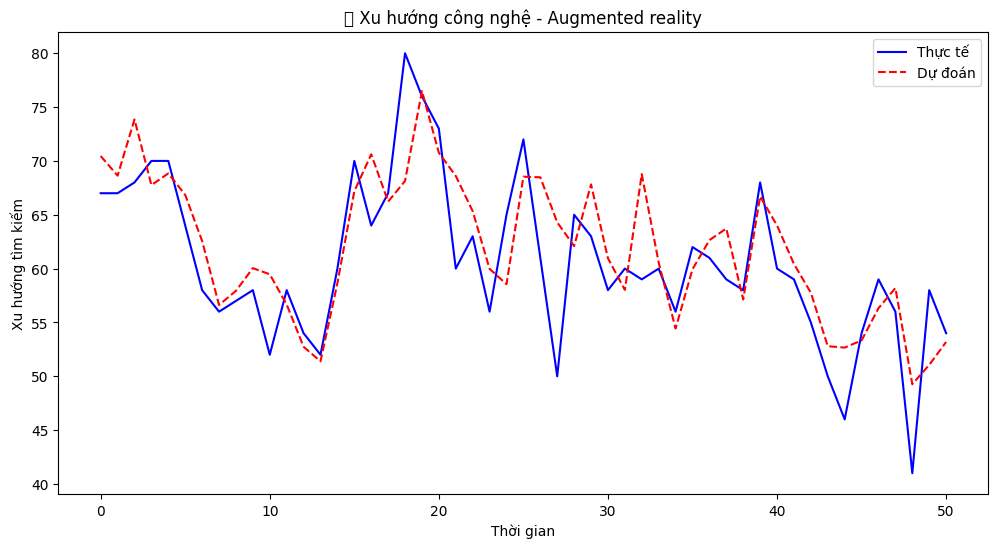

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


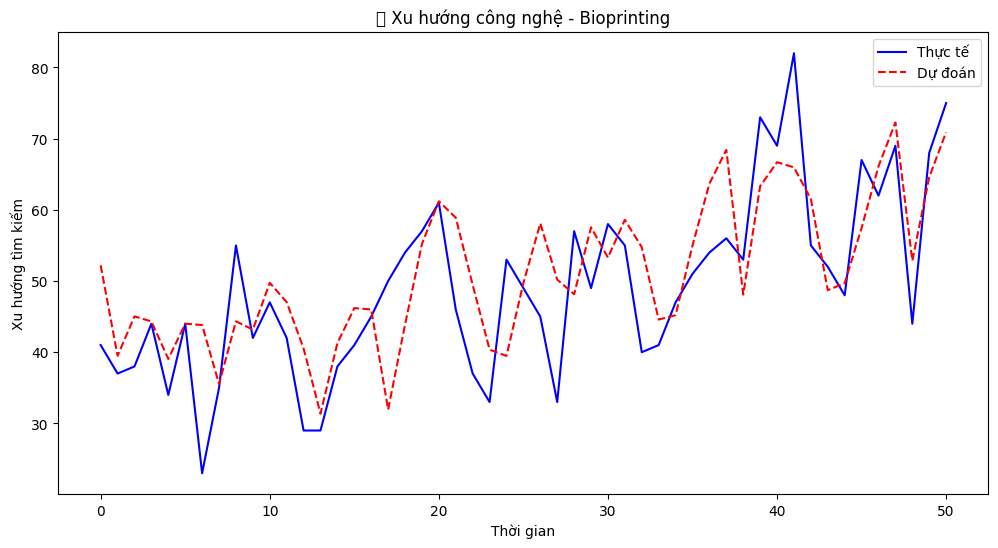

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


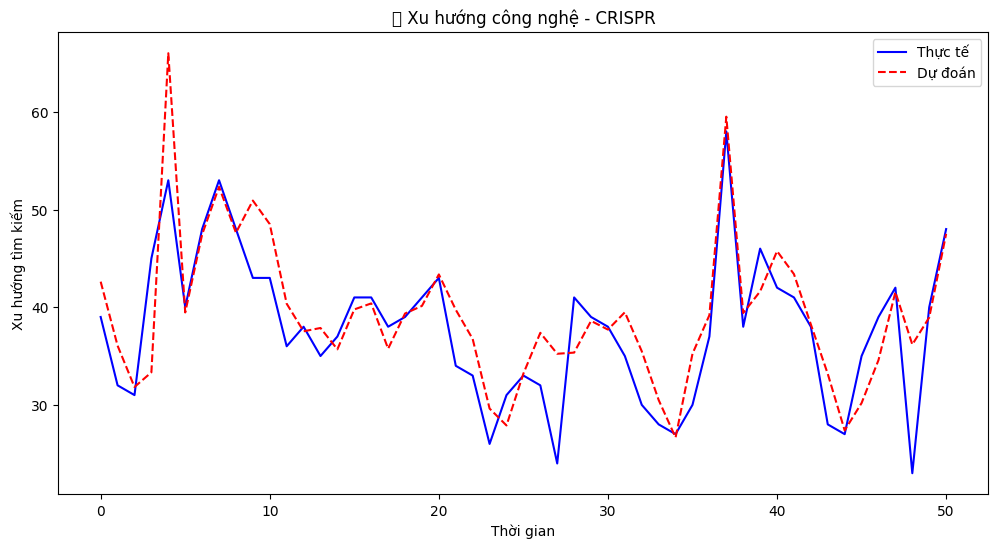

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


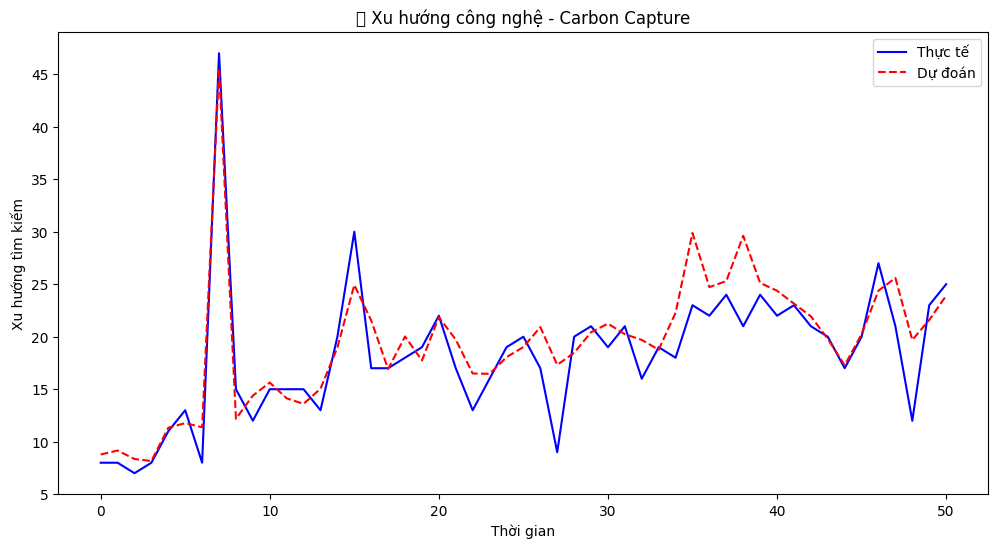

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


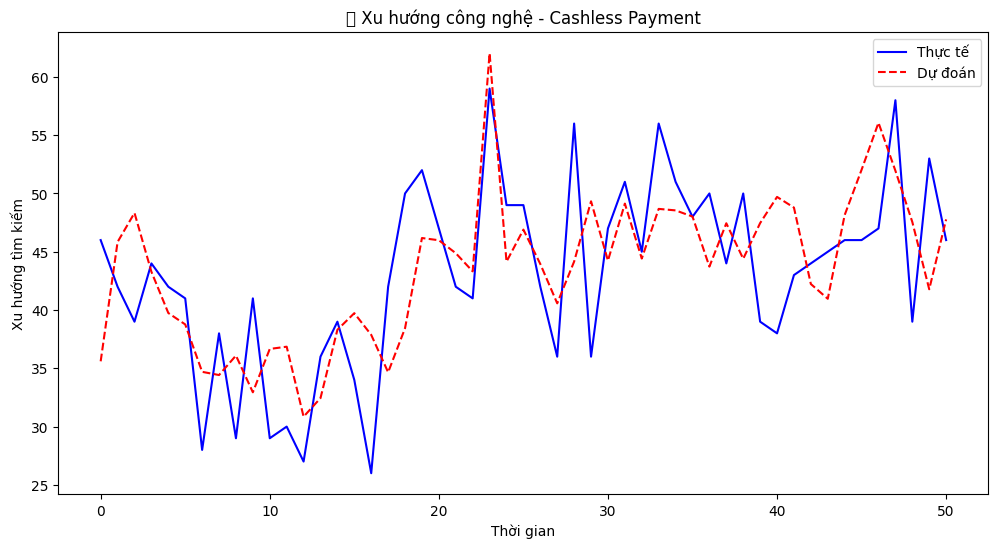

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


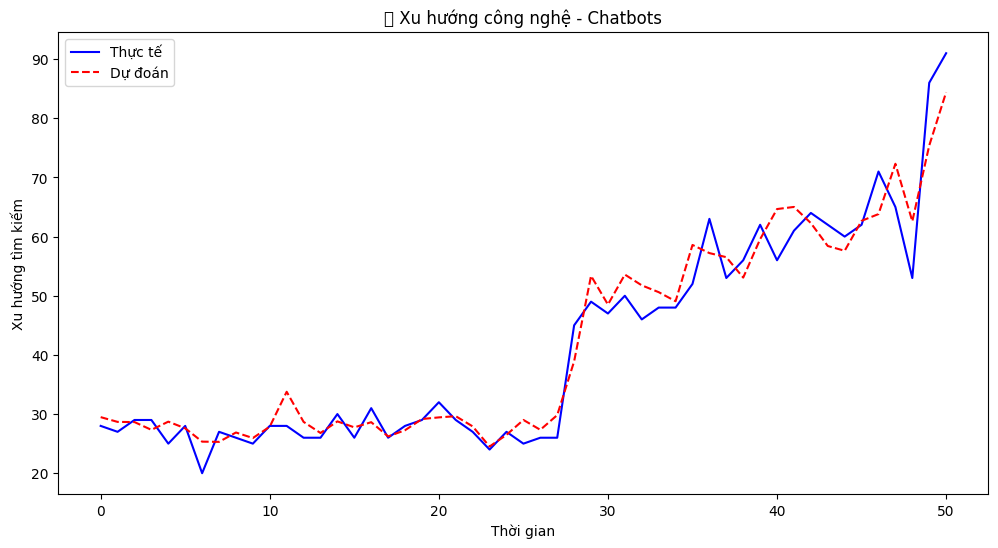

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


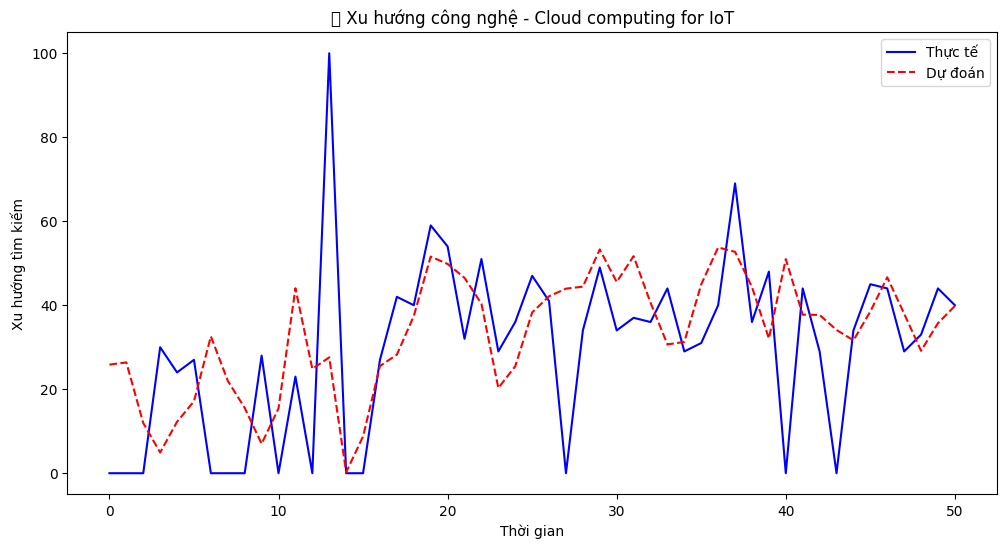

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


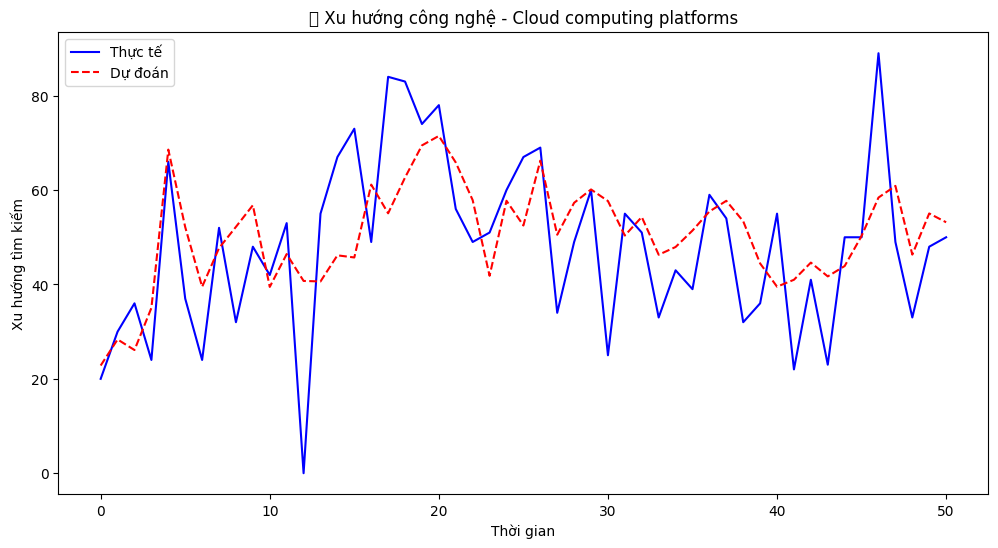

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


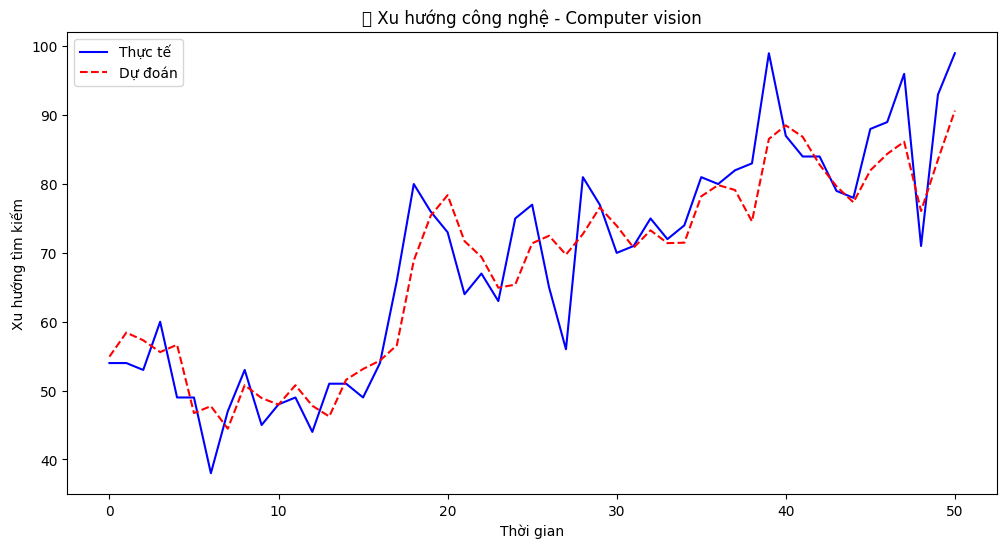

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


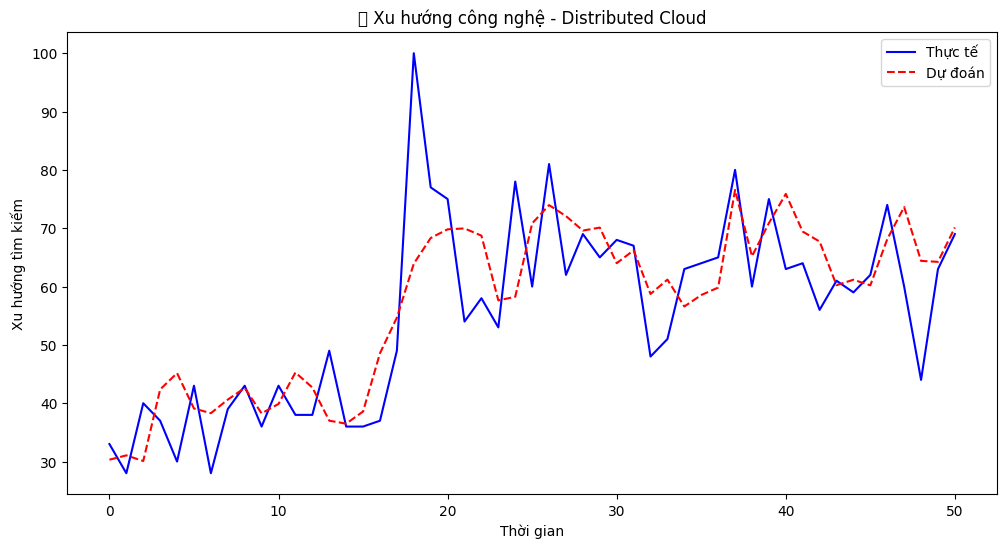

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


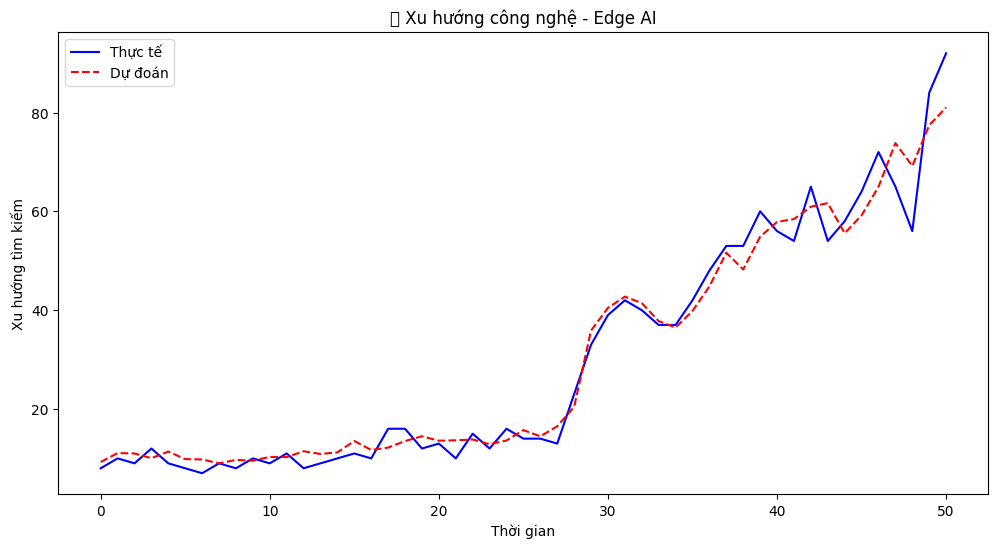

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


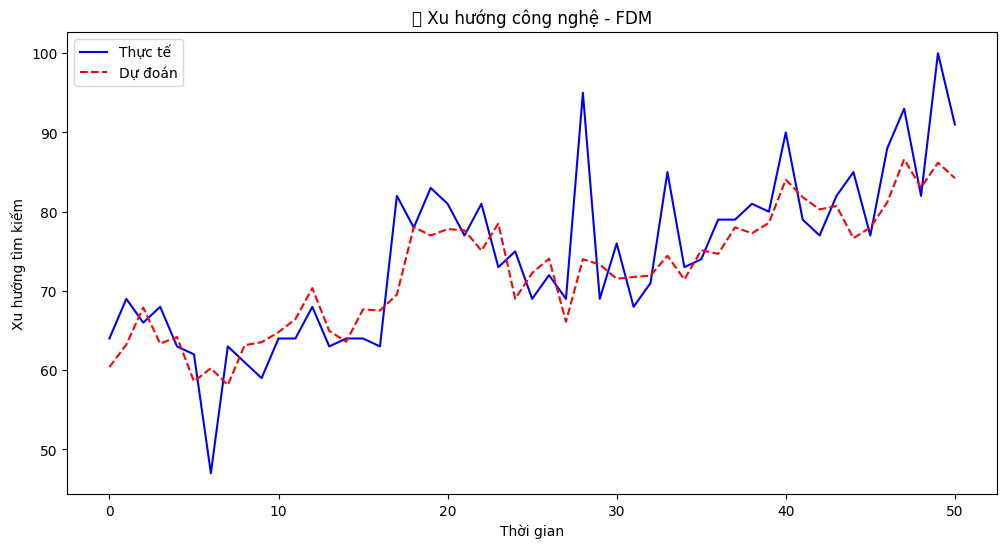

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


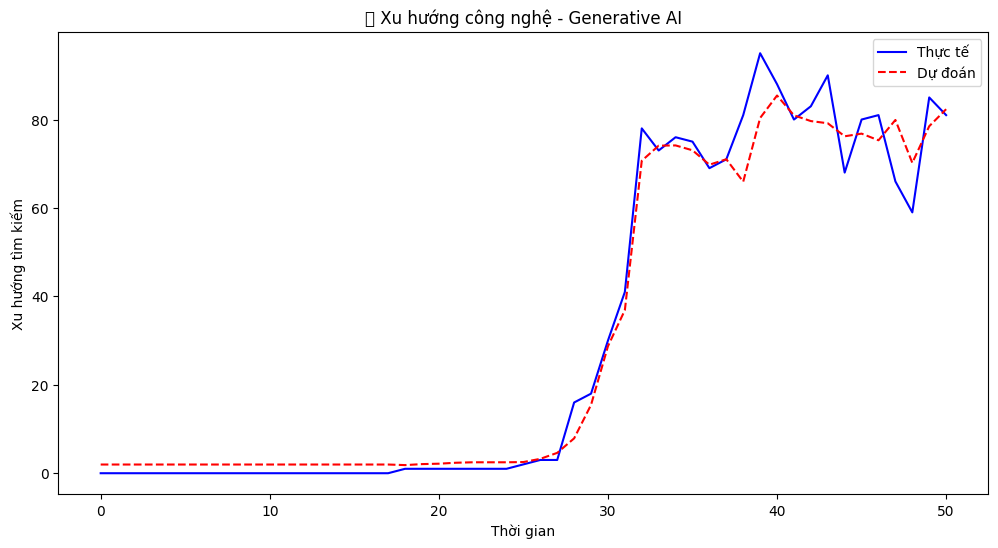

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


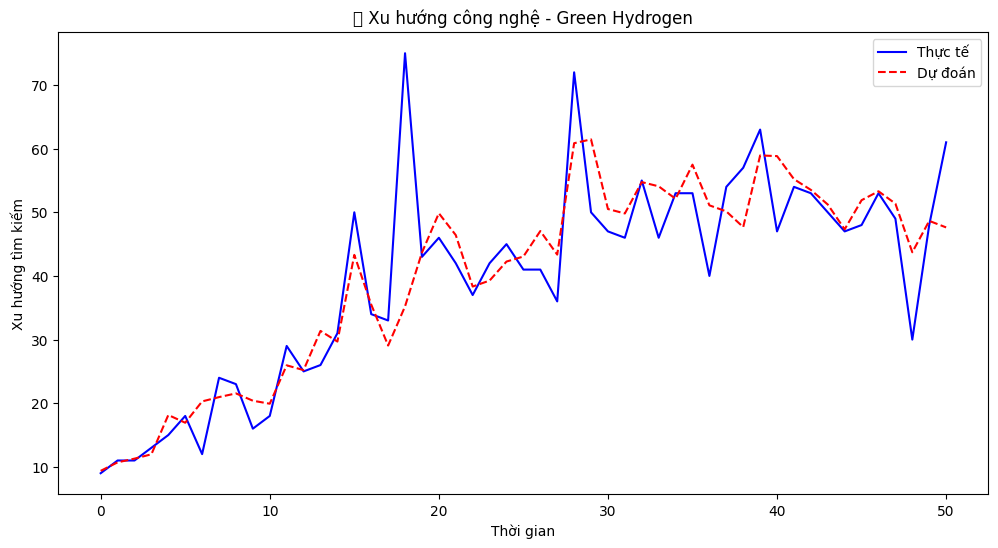

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


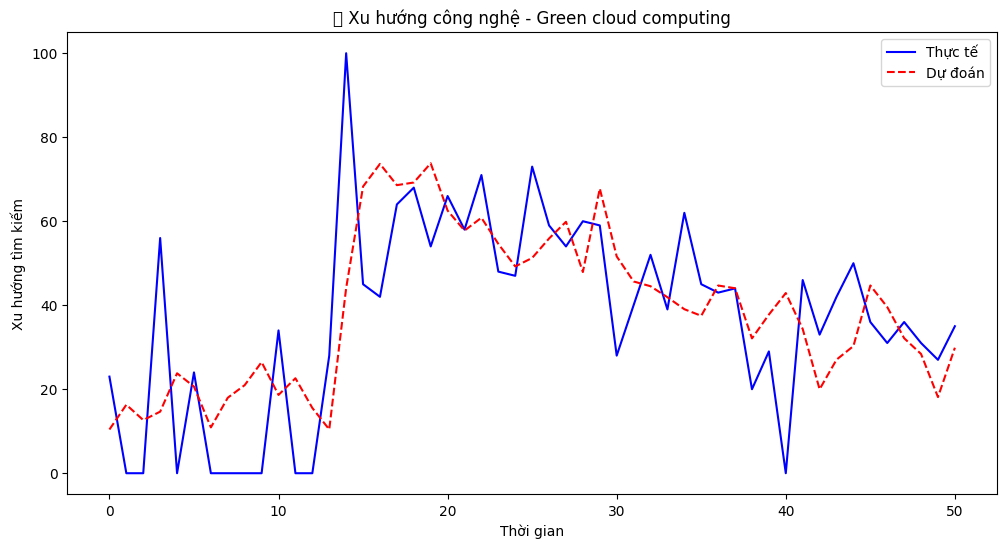

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


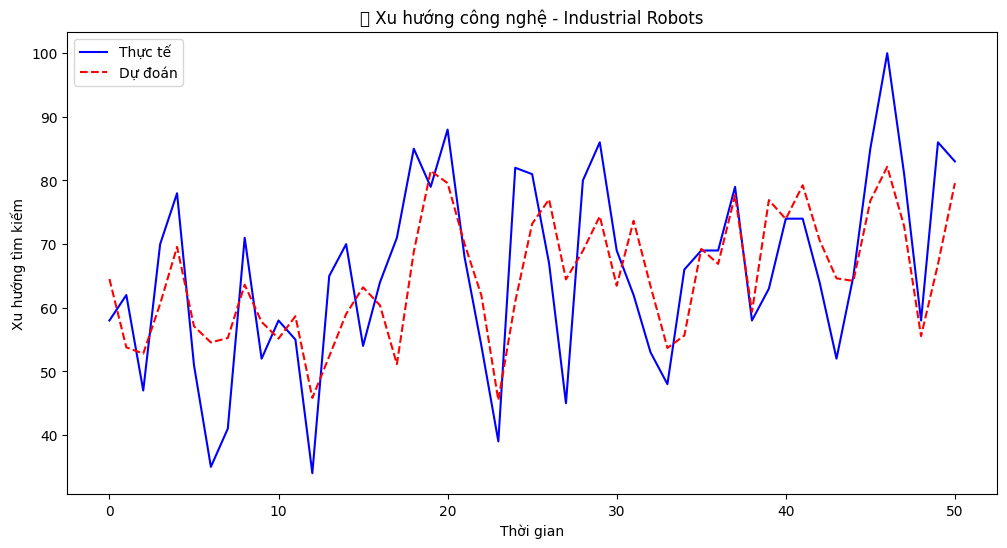

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


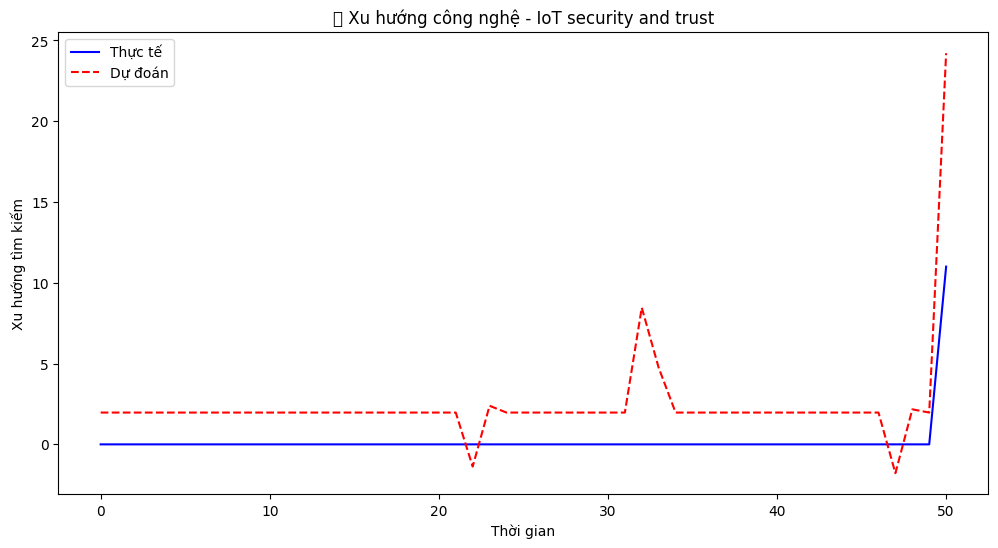

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


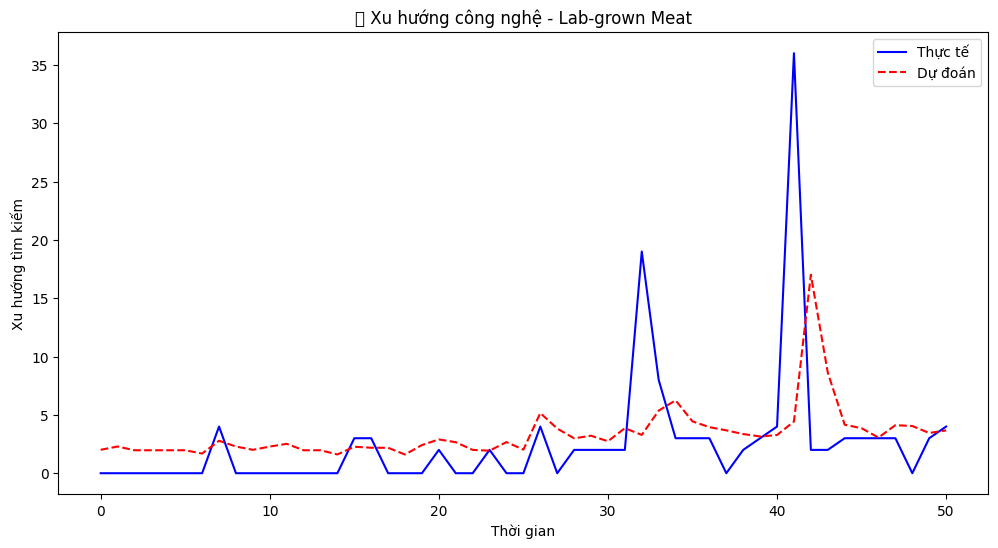

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


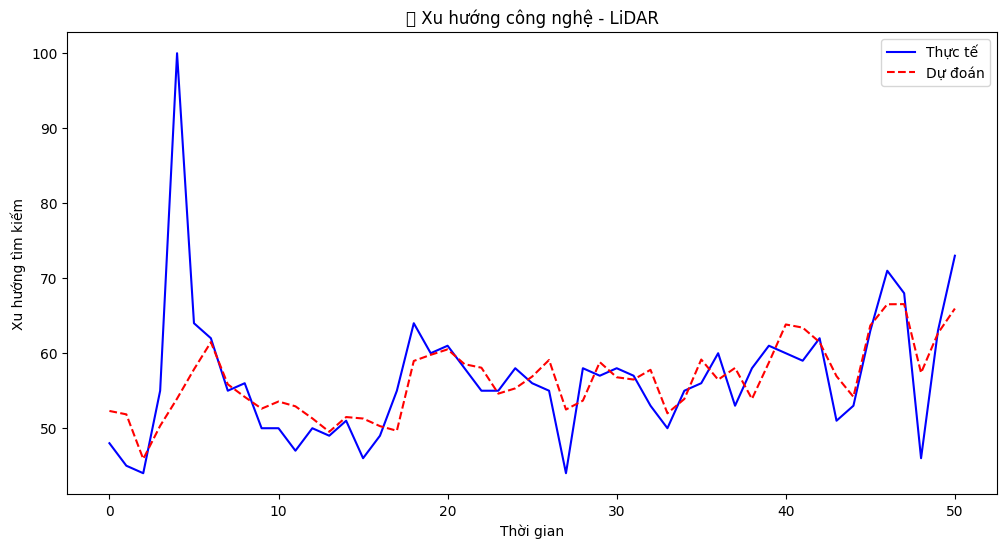

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


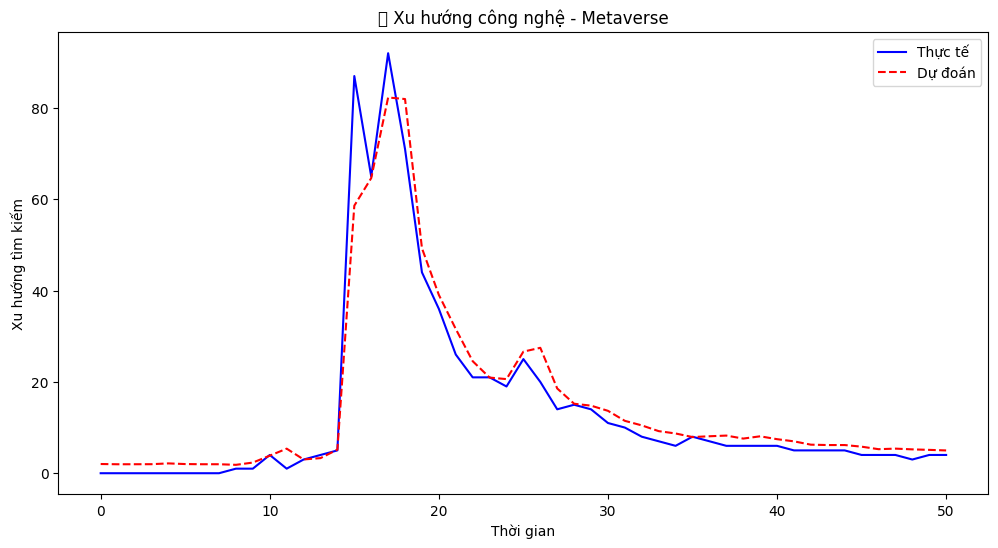

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


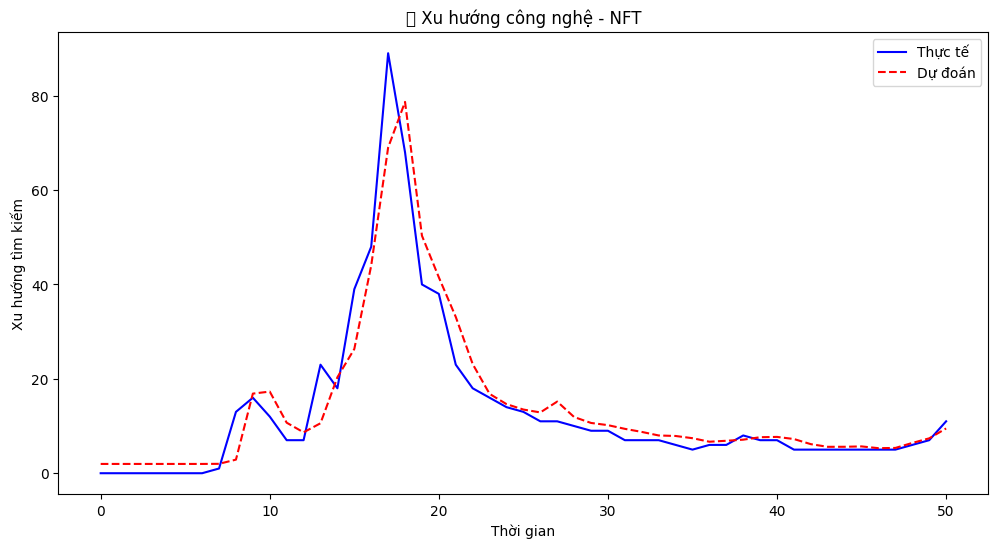

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


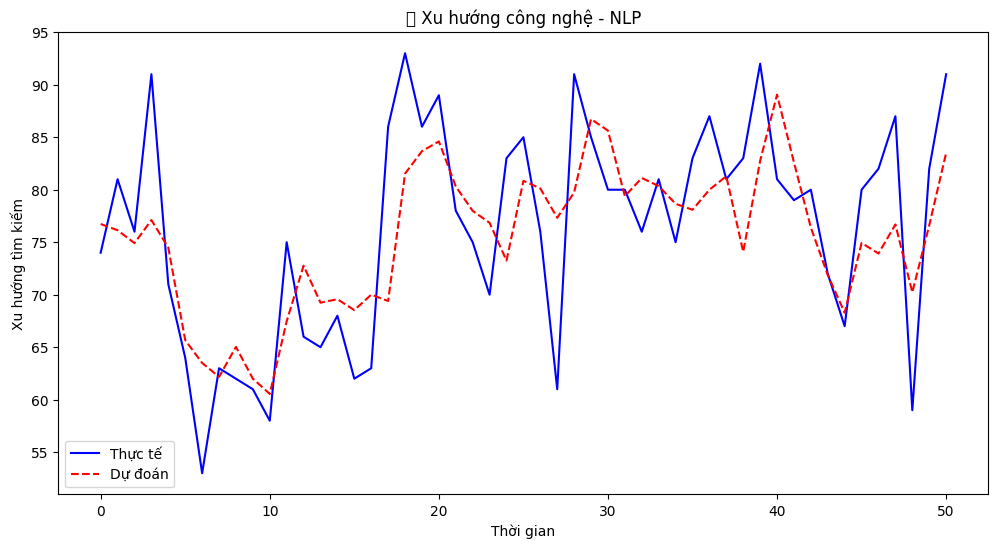

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


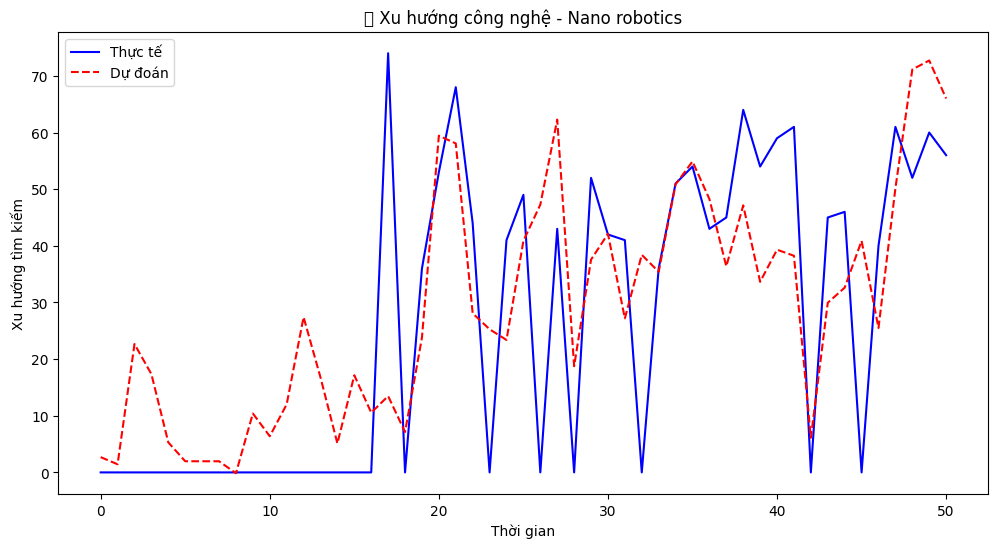

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


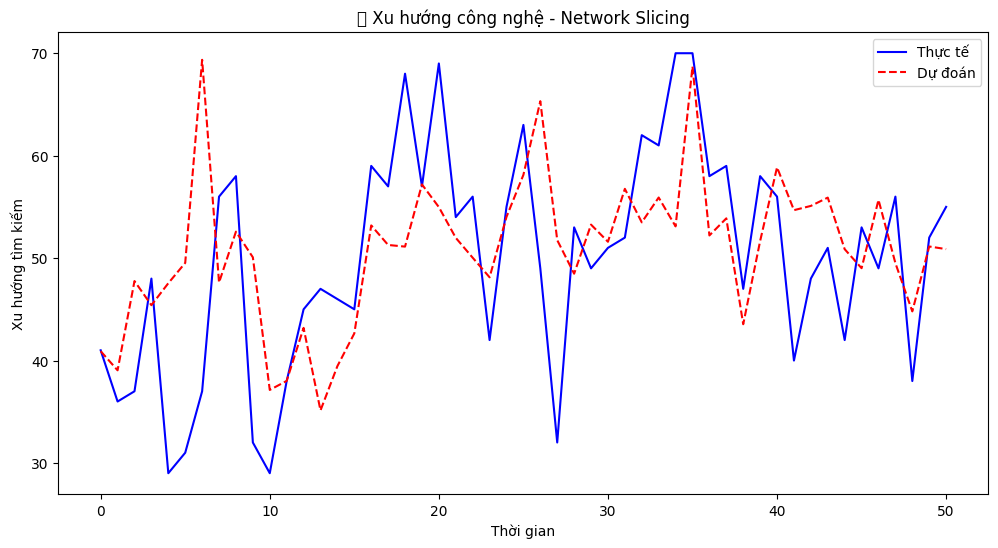

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


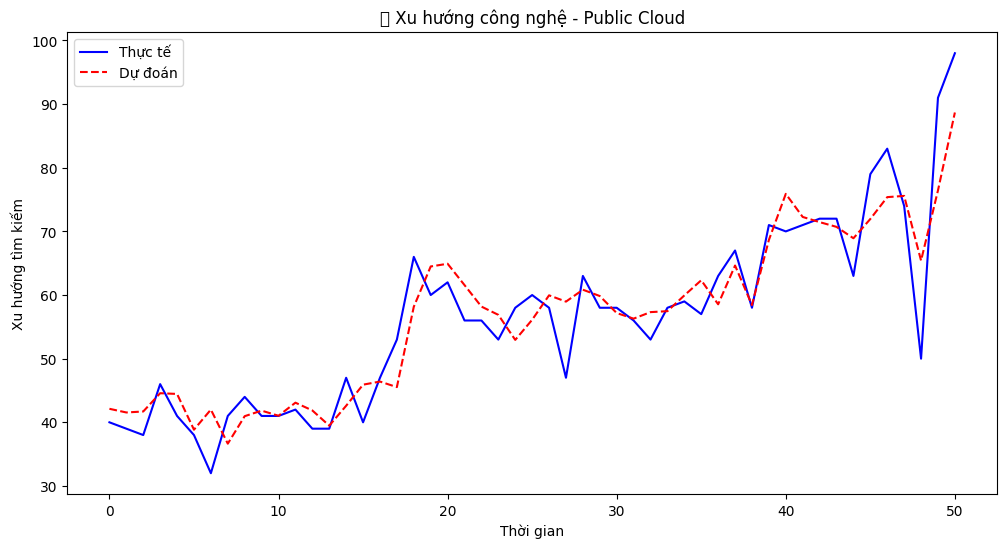

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


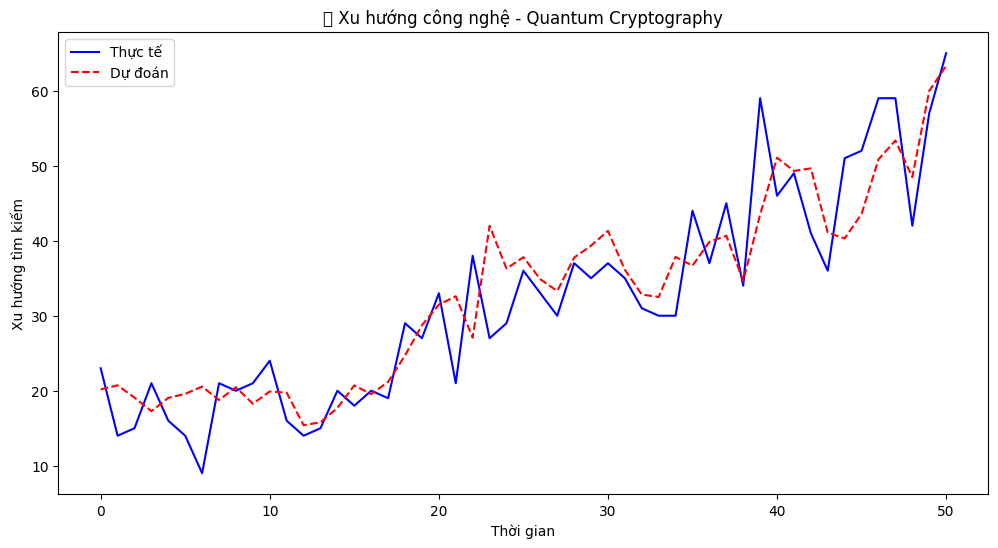

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


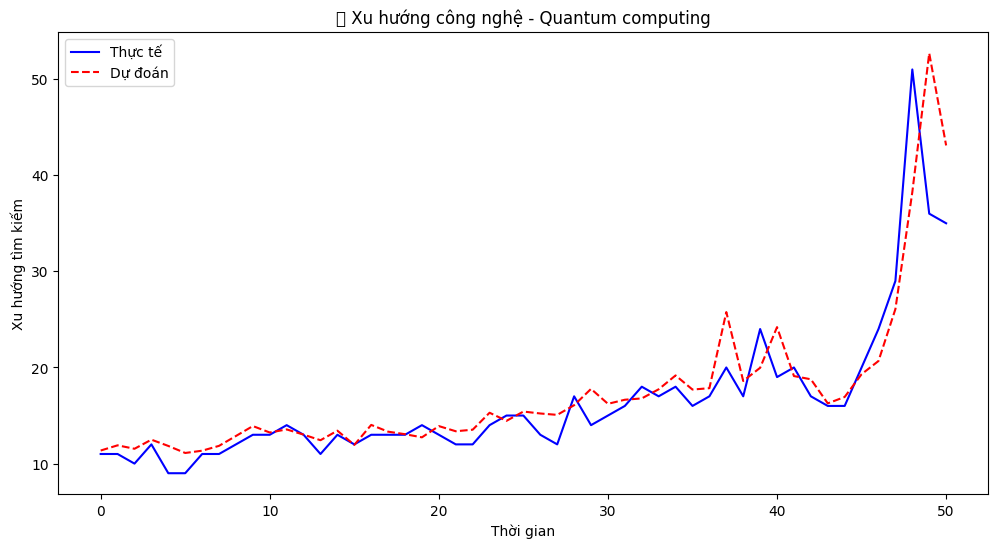

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


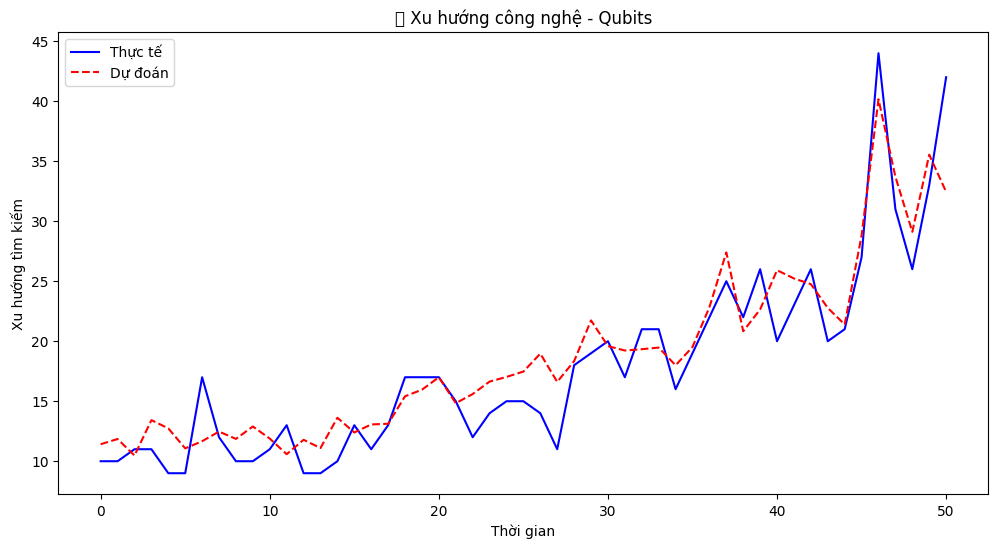

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


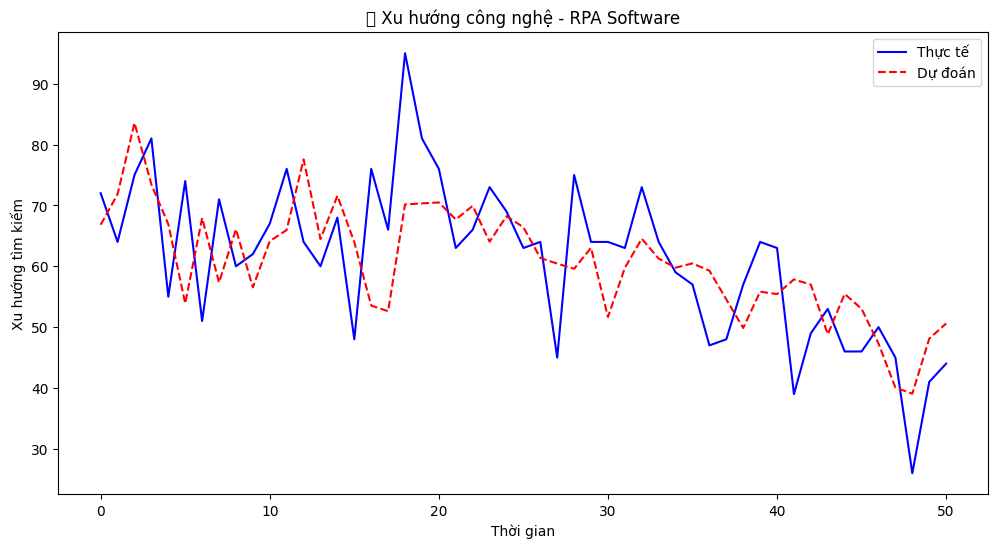

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


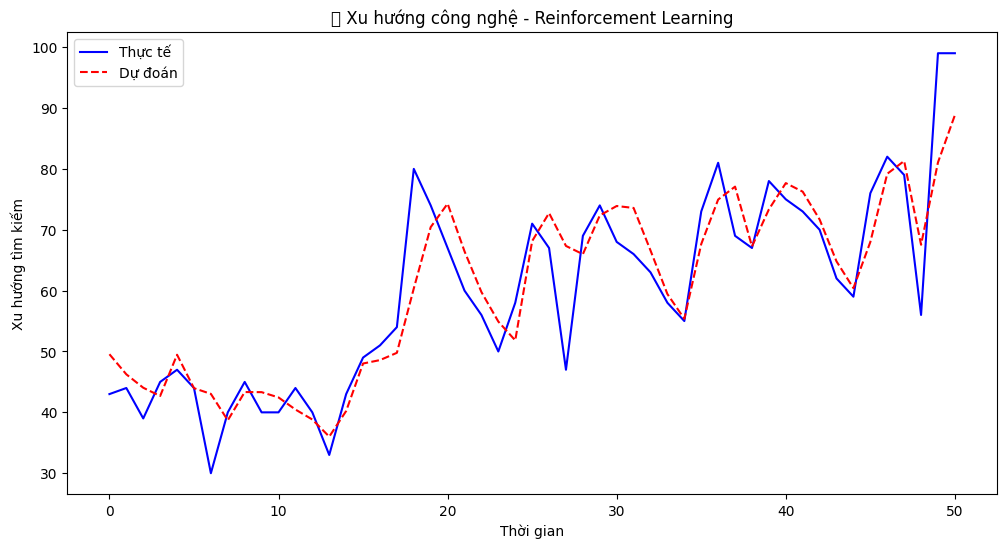

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


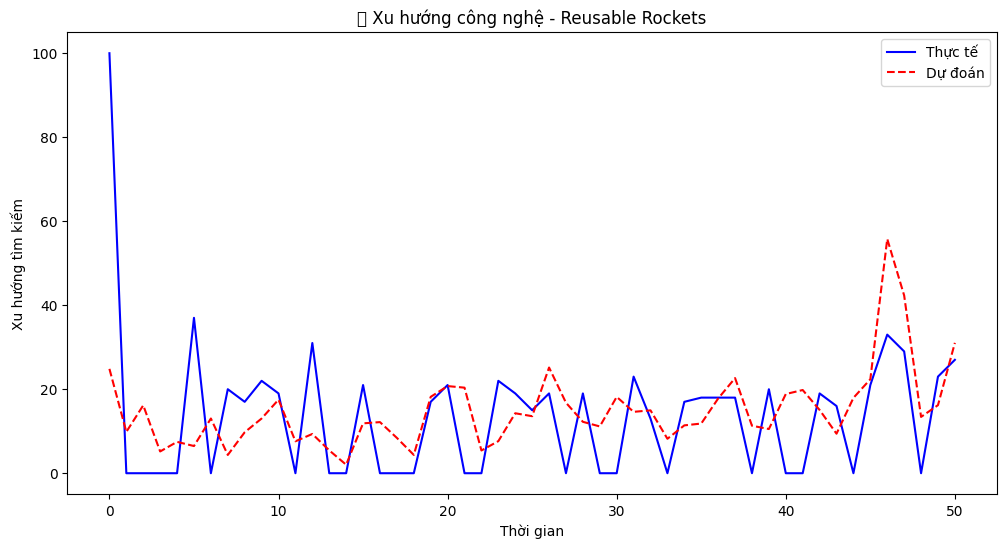

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


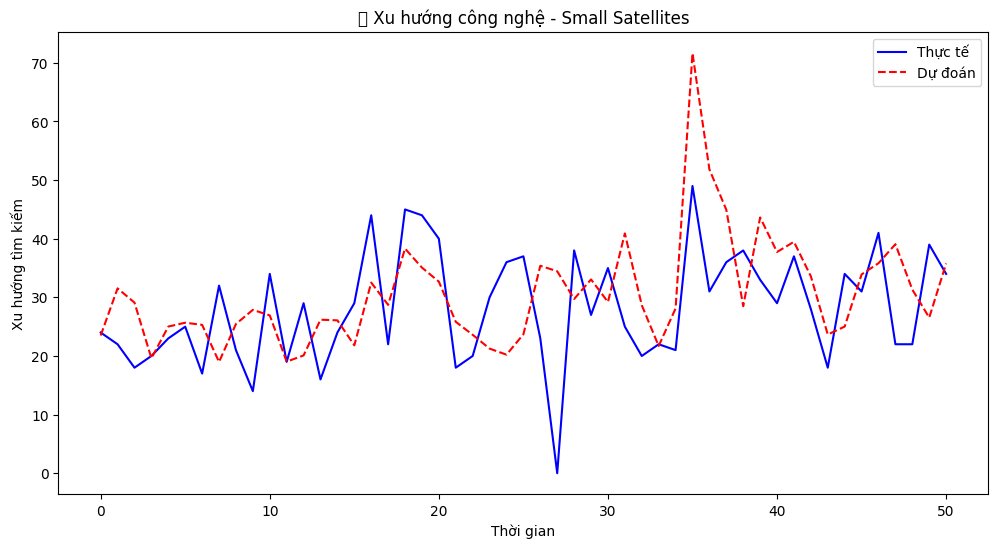

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


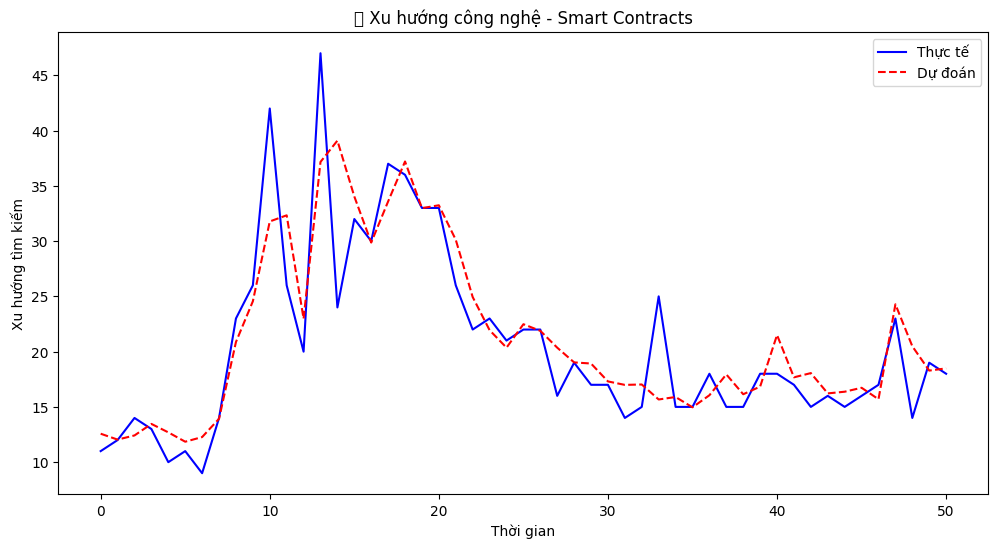

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


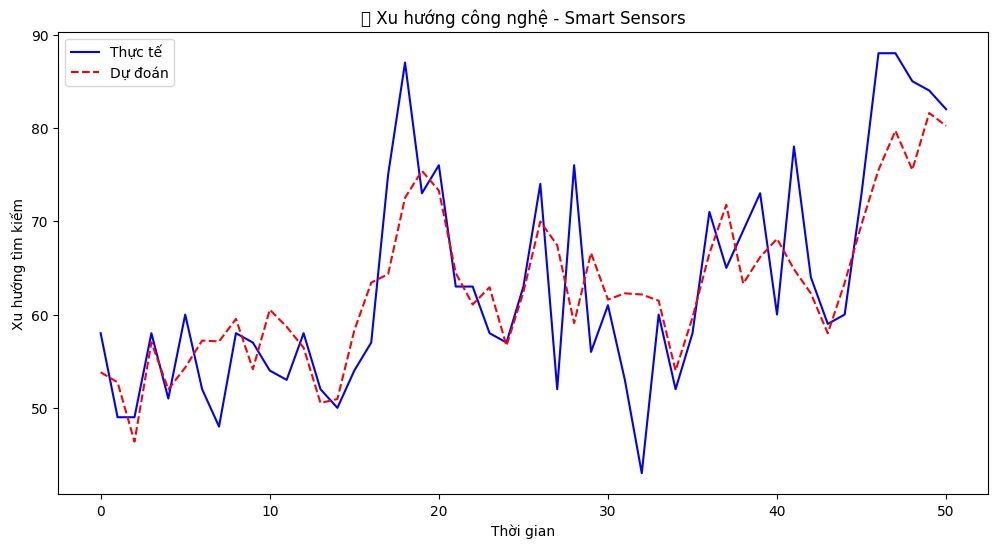

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


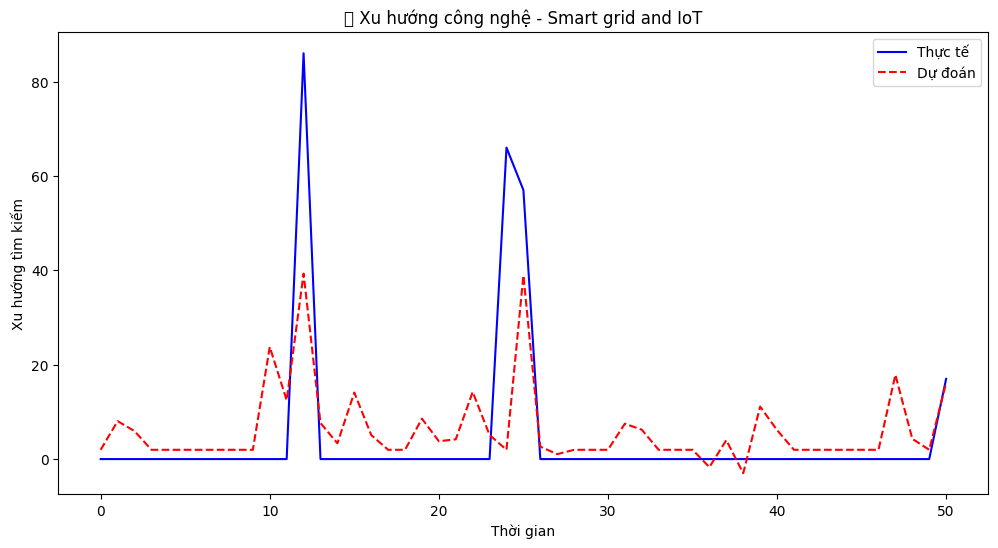

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


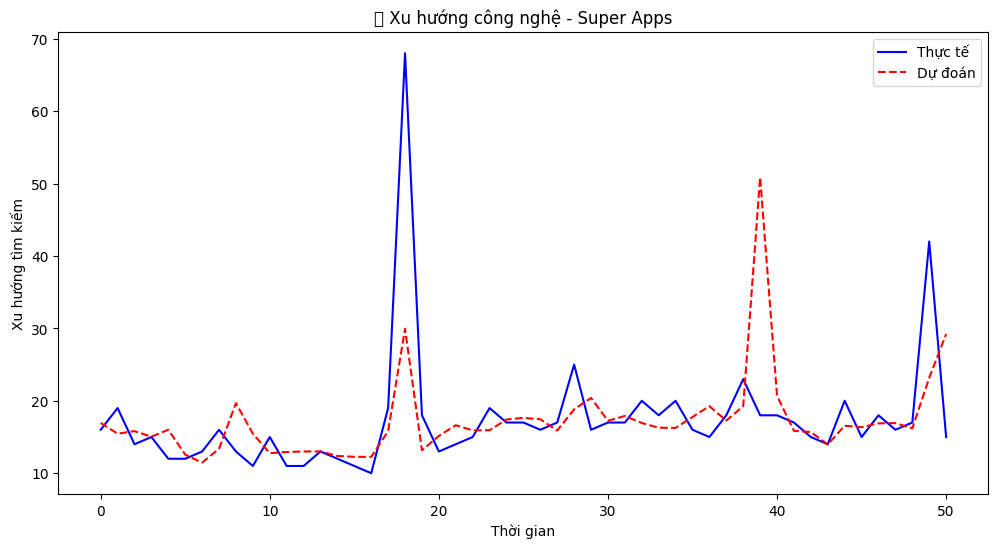

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


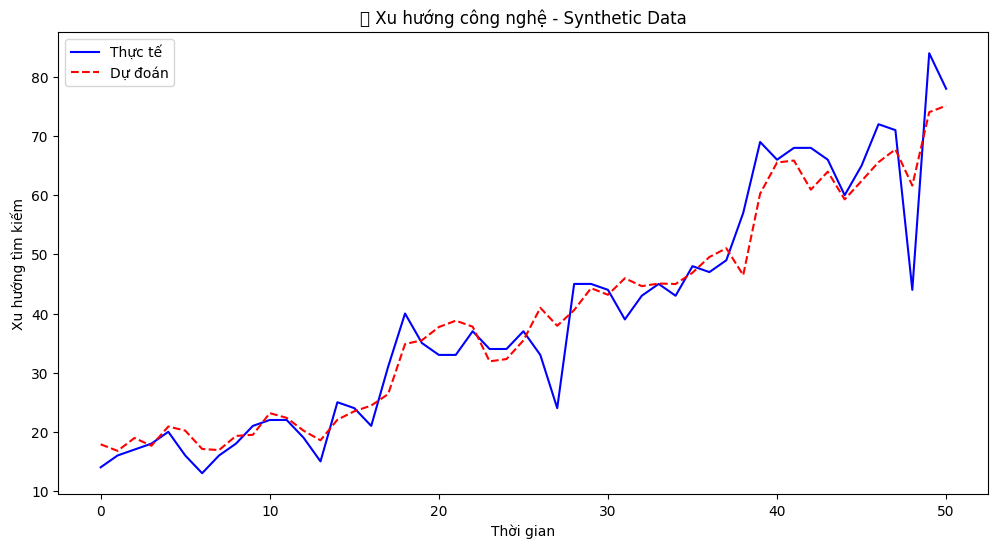

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


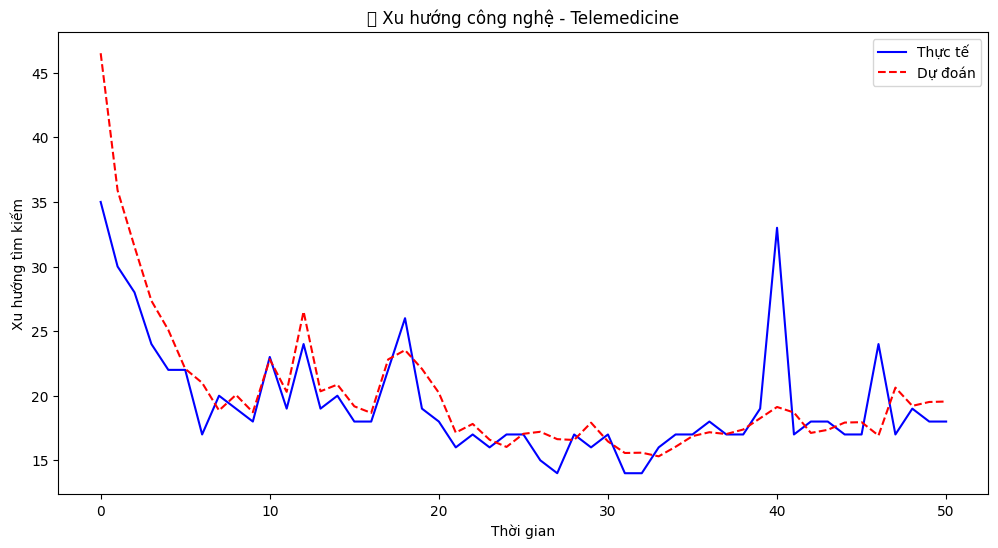

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


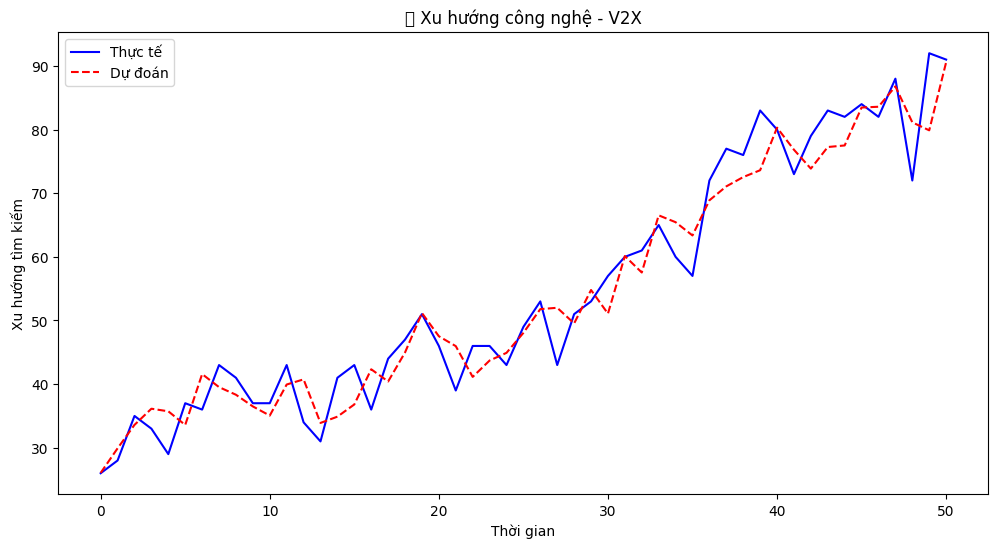

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


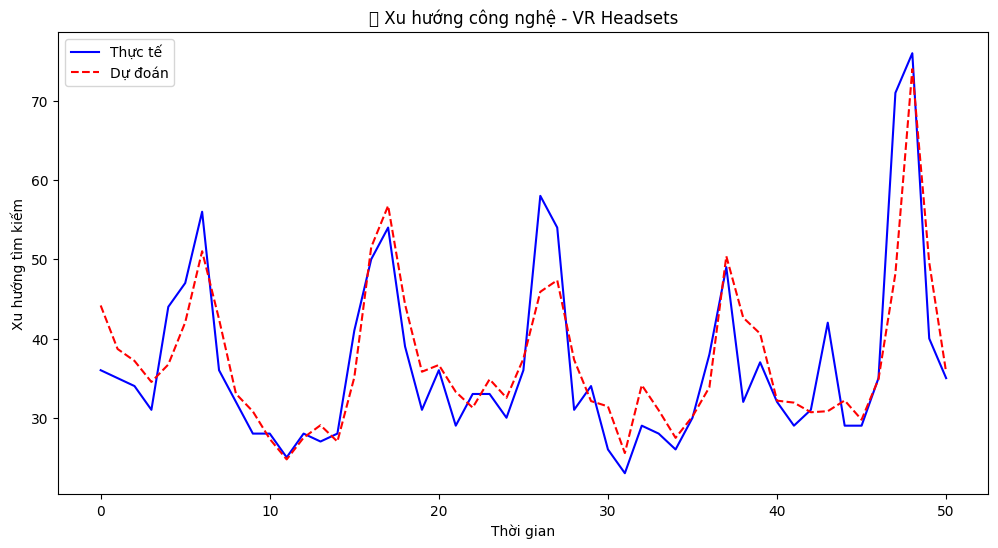

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


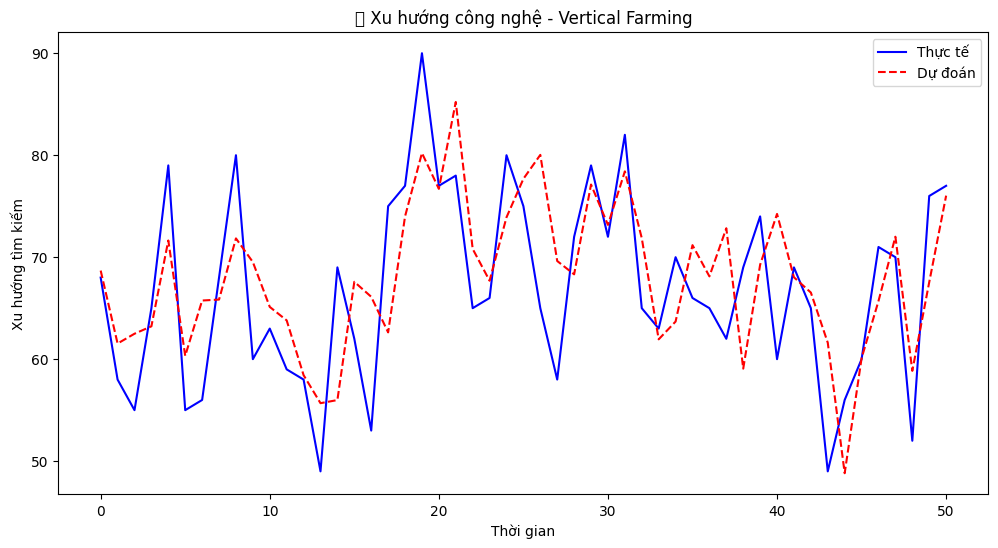

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


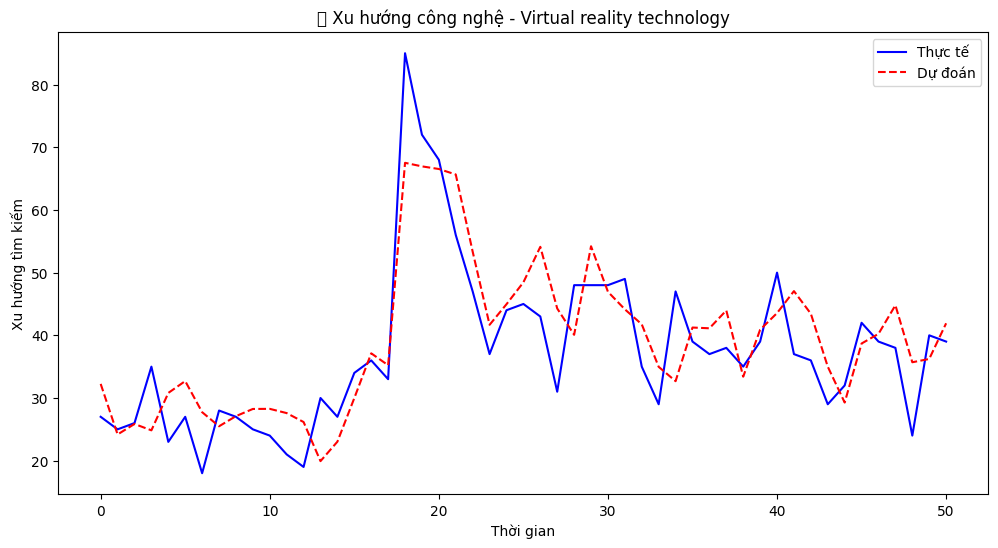

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


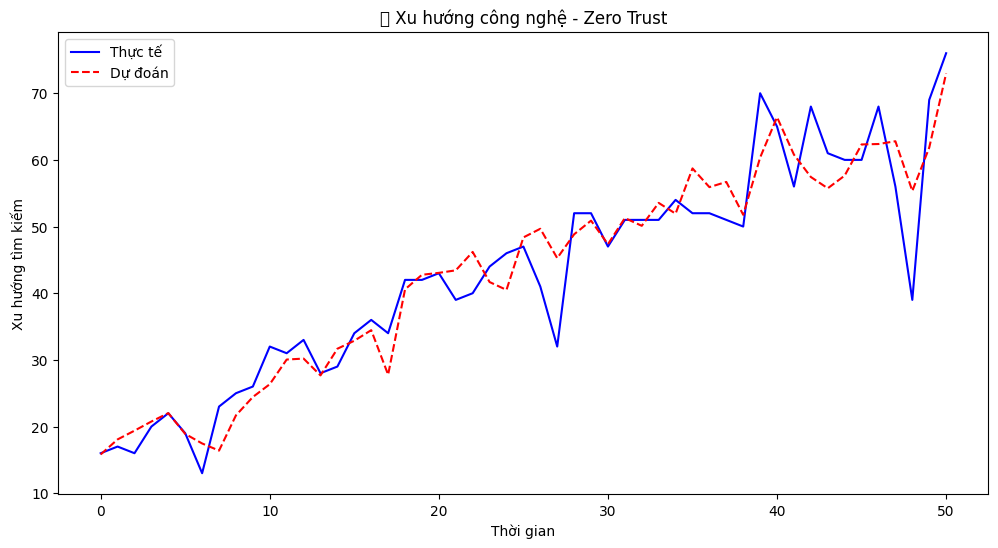

In [ ]:
# 10. Vẽ biểu đồ dự đoán xu hướng cho từng từ khóa
for keyword in keywords:
    data = df_cleaned[df_cleaned['keyword'] == keyword]['trend_value_scaled'].values
    X, y = create_sequences(data, window_size, step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    y_pred_keyword = model.predict(X)

    # Chuyển đổi về thang đo gốc
    # Thay 'scaler' bằng 'scaler_y' vì chúng ta đang chuyển đổi giá trị Interest Over Time
    y_pred_keyword_original = scaler_y.inverse_transform(y_pred_keyword.reshape(-1, 1)) # Changed 'scaler' to 'scaler_y'
    y_original = scaler_y.inverse_transform(y.reshape(-1, 1)) # Changed 'scaler' to 'scaler_y'

    plt.figure(figsize=(12, 6))
    plt.plot(y_original, label="Thực tế", color='blue')
    plt.plot(y_pred_keyword_original, label="Dự đoán", linestyle='dashed', color='red')
    plt.title(f"📈 Xu hướng công nghệ - {keyword}")
    plt.xlabel("Thời gian")
    plt.ylabel("Xu hướng tìm kiếm")
    plt.legend()
    plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


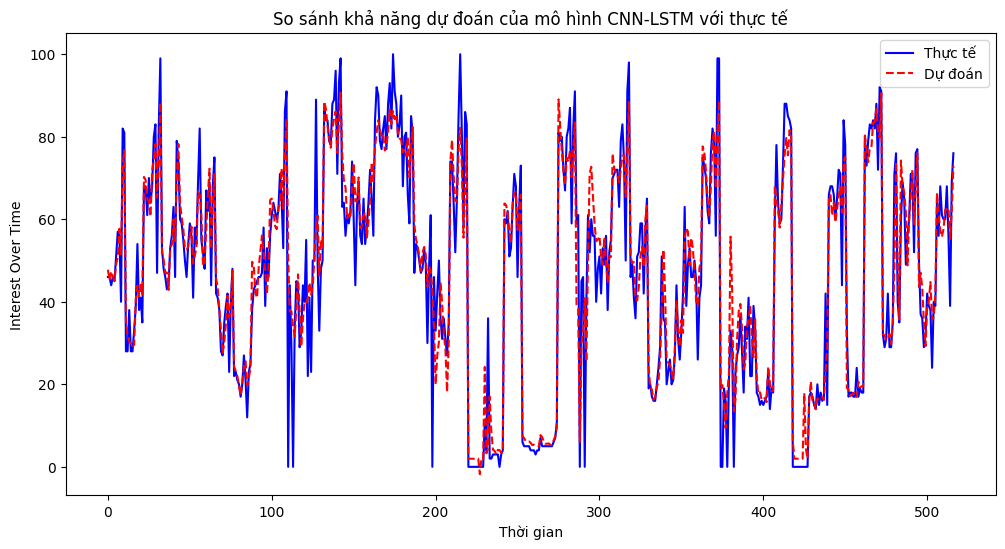

In [ ]:
# Dự đoán kết quả với mô hình CNN-LSTM
y_pred = model.predict(X_test)

# Chuyển về thang đo gốc using scaler_y
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)) # Changed 'scaler' to 'scaler_y'
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)) # Changed 'scaler' to 'scaler_y'

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Thực tế", color='blue')
plt.plot(y_pred_original, label="Dự đoán", color='red', linestyle='dashed')
plt.title("So sánh khả năng dự đoán của mô hình CNN-LSTM với thực tế")
plt.xlabel("Thời gian")
plt.ylabel("Interest Over Time")
plt.legend()
plt.show()